In [32]:
# load necessary libraries
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from collections import defaultdict
from sentence_transformers import models, SentenceTransformer
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import Dataset, DataLoader, Sampler
import torch.optim as optim
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import umap
from tqdm import tqdm

# load the dictionary terms
groups_dictionary = pd.read_csv("../01_data/dictionary/groups_dictionary_cl_augmentations.csv")

# load the ground truth data with augmentations
with open("../01_data/annotations/annotations_augmentations.json") as f:
    gt_augmentations = json.load(f)

In [33]:
# create a single list of all dictionary entries paired with their category
mention_list = []
category_list = []
categories = groups_dictionary.columns
cat2id = {c: i for i, c in enumerate(categories)}
for category in categories:
    for idx, row in groups_dictionary[[category]].iterrows():
        if not pd.isna(row.values):
            entry = row.values[0]
            mention_list.append(entry.strip())
            category_list.append(category)

category_list = [cat for cat in category_list]

df = pd.DataFrame({'mention': mention_list, 'category': category_list})

mention_list = df["mention"].to_list()
category_list = df["category"].to_list()

In [76]:
class SBERTDataset(Dataset):
    def __init__(self, mentions, labels, cat2id):
        self.mentions = mentions
        self.label_ids = [cat2id[l] for l in labels]

    def __len__(self):
        return len(self.mentions)

    def __getitem__(self, idx):
        return self.mentions[idx], self.label_ids[idx]
    

category_to_indices = defaultdict(list)

for idx, cat in enumerate(category_list):
    category_to_indices[cat].append(idx)


class BalancedBatchSampler(Sampler):
    def __init__(self, category_to_indices, categories_per_batch, samples_per_category, batches_per_epoch):
        self.category_to_indices = category_to_indices
        self.categories = list(category_to_indices.keys())
        self.categories_per_batch = categories_per_batch
        self.samples_per_category = samples_per_category
        self.batches_per_epoch = batches_per_epoch

    def __len__(self):
        return self.batches_per_epoch

    def __iter__(self):
        for _ in range(self.batches_per_epoch):
            batch_indices = []
            selected_cats = random.sample(self.categories, self.categories_per_batch)
            for cat in selected_cats:
                indices = self.category_to_indices[cat]
                chosen = random.sample(indices, k=self.samples_per_category)
                batch_indices.extend(chosen)
            yield batch_indices


def sbert_collate_fn(batch):
    mentions, label_ids = zip(*batch)
    return list(mentions), torch.tensor(label_ids)


class SBERTEncoder(nn.Module):
    def __init__(self, model_name="sentence-transformers/all-mpnet-base-v2", proj_dim=128):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.encoder = AutoModel.from_pretrained(model_name)

        hidden_size = self.encoder.config.hidden_size
        self.projector = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, proj_dim)
        )

    def forward(self, sentences):
        # Tokenize
        encoding = self.tokenizer(
            sentences,
            padding=True,
            truncation=True,
            return_tensors="pt"
        )
        # Move to device
        device = next(self.projector.parameters()).device
        for key in encoding:
            encoding[key] = encoding[key].to(device)

        # Forward pass
        outputs = self.encoder(**encoding)
        last_hidden = outputs.last_hidden_state

        # Mean pooling with attention mask
        mask = encoding['attention_mask'].unsqueeze(-1)
        h = (last_hidden * mask).sum(1) / mask.sum(1)

        # Projection
        z = self.projector(h)
        return h, z


def supervised_contrastive_loss(embeddings, labels, temperature=0.1):
    embeddings = F.normalize(embeddings, dim=1)
    sim_matrix = torch.matmul(embeddings, embeddings.T) / temperature

    labels = labels.unsqueeze(1)
    
    mask = torch.eq(labels, labels.T).float()
    mask.fill_diagonal_(0)

    pos_counts = mask.sum(1)
    valid = pos_counts > 0
    pos_counts = torch.clamp(pos_counts, min=1)

    log_prob = F.log_softmax(sim_matrix, dim=1)
    mean_log_prob_pos = (mask * log_prob).sum(1) / pos_counts
    loss = -mean_log_prob_pos[valid].mean()
    return loss

In [79]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# UNBALANCED
dataset = SBERTDataset(mention_list, category_list, cat2id)
dataloader = DataLoader(
    dataset=dataset,
    batch_size=128,
    shuffle=True,
    #drop_last=True
)

In [70]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

# BALANCED
dataset = SBERTDataset(mention_list, category_list, cat2id)
dataloader = DataLoader(
    dataset,
    batch_sampler=BalancedBatchSampler(category_to_indices, categories_per_batch=10, samples_per_category=4, batches_per_epoch=10),
    collate_fn=sbert_collate_fn
)

In [80]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = SBERTEncoder(proj_dim=128).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)

for epoch in range(50):
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")

    for batch in progress_bar:

        sentences, batch_labels = batch
        batch_labels = batch_labels.to(device)

        # clear grad
        optimizer.zero_grad()

        # SBERT.encode() already uses float32; keep autocast off on MPS
        h, z = model(sentences)
        z = z.to(device)

        # loss
        loss = supervised_contrastive_loss(z, batch_labels)
        total_loss += loss.item()

        # backward
        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}, Average Batch Loss: {avg_loss:.4f}")


Epoch 1: 100%|██████████| 3/3 [00:04<00:00,  1.52s/it, loss=4.12]


Epoch 1, Average Batch Loss: 4.2433


Epoch 2: 100%|██████████| 3/3 [00:01<00:00,  2.92it/s, loss=3.86]


Epoch 2, Average Batch Loss: 3.9743


Epoch 3: 100%|██████████| 3/3 [00:01<00:00,  1.74it/s, loss=3.55]


...

Epoch 48, Average Batch Loss: 1.4821


Epoch 49: 100%|██████████| 3/3 [00:00<00:00,  3.54it/s, loss=1.51]


Epoch 49, Average Batch Loss: 1.4860


Epoch 50: 100%|██████████| 3/3 [00:00<00:00,  3.43it/s, loss=1.41]

Epoch 50, Average Batch Loss: 1.4613


In [81]:
#model = SBERTEncoder(proj_dim=128).to(device)
model.eval()

with torch.no_grad():
    all_embeddings = []

    for batch in dataloader:
        sentences, batch_labels = batch
        batch_labels = batch_labels.to(device)
        h, z = model(sentences)
        all_embeddings.append(z.cpu())

all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
labels_np = np.array([cat2id[cat] for cat in category_list])

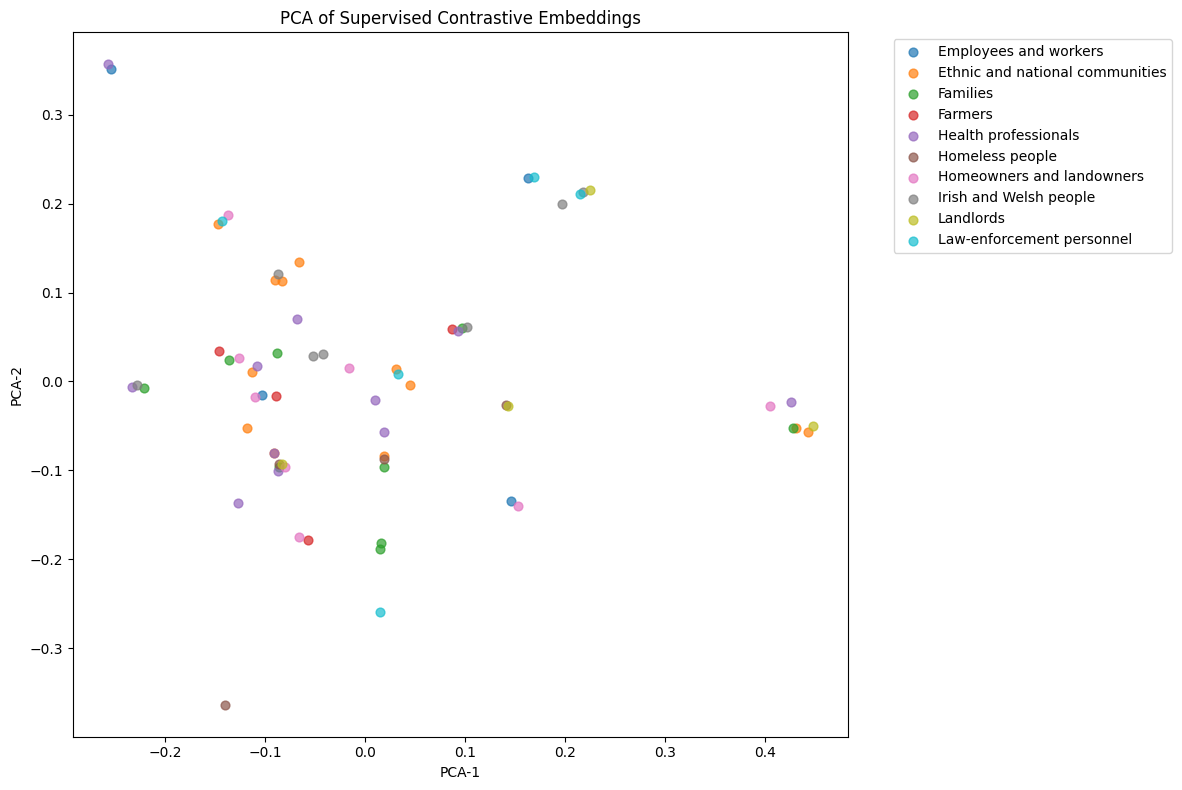

In [82]:
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(all_embeddings)


plt.figure(figsize=(12, 8))
categories = list(cat2id.keys())
num_classes = len(categories)

for c in range(10, 20):
    idx = np.where(labels_np == c)[0]
    if len(idx) == 0:
        continue
    plt.scatter(
        emb_2d[idx, 0],
        emb_2d[idx, 1],
        label=categories[c],
        alpha=0.7,
        s=40
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.title("PCA of Supervised Contrastive Embeddings")
plt.tight_layout()
plt.show()

In [83]:
dbscan = DBSCAN(eps=.1, min_samples=3, metric='cosine') 
labels = dbscan.fit_predict(all_embeddings)

cluster_dict = defaultdict(list)

for mention, label in zip(mention_list, labels):
    cluster_dict[label].append(mention)

for cluster_id, mentions in cluster_dict.items():
    print(f"Cluster {cluster_id} ({len(mentions)} mentions):")
    for mention in mentions:
        print(f"  - {mention}")
    print()

Cluster 0 (8 mentions):
  - adults
  - africans
  - GPs
  - childless couples
  - irish emigrant
  - all those paying taxes
  - taxpayers in our country
  - people without employment

Cluster 1 (13 mentions):
  - middle-aged people
  - persons of mature age
  - bangledeshi
  - queer
  - working class
  - people on poverty wages
  - people on low incomes
  - special constables
  - addicts
  - invalids
  - bicyclists
  - journalists
  - long-term unemployed

Cluster 2 (12 mentions):
  - grown-ups
  - working class
  - ranchers
  - houseowners
  - low income class
  - social welfare recipients
  - technicians
  - middle class
  - physically or mentally disabled
  - unemployed person
  - high income earners
  - barristers

Cluster 3 (26 mentions):
  - therapists
  - victims of crime
  - victims of violent crime
  - prisoners
  - retirees
  - bosses
  - business people
  - people living on the street
  - police officers
  - asexual
  - truck drivers
  - migrants
  - illegal aliens
  - milit